<a href="https://colab.research.google.com/github/tjdux/Introduction-to-Machine-Learning-with-Python/blob/main/03_4_%EC%B0%A8%EC%9B%90_%EC%B6%95%EC%86%8C%2C_%ED%8A%B9%EC%84%B1_%EC%B6%94%EC%B6%9C%2C_%EB%A7%A4%EB%8B%88%ED%8F%B4%EB%93%9C_%ED%95%99%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 노트북이 코랩에서 실행 중인지 체크합니다.
import os
import sys
if 'google.colab' in sys.modules and not os.path.isdir('mglearn'):
    # mglearn을 다운받고 압축을 풉니다.
    !wget -q -O mglearn.tar.gz https://bit.ly/mglearn-tar-gz
    !tar -xzf mglearn.tar.gz
    !wget -q -O data.tar.gz https://bit.ly/data-tar-gz
    !tar -xzf data.tar.gz
    # 나눔 폰트를 설치합니다.
    !sudo apt-get -qq -y install fonts-nanum
    import matplotlib.font_manager as fm
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 120925 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [2]:
import sklearn
from preamble import *
import matplotlib

# 나눔 폰트를 사용합니다.
matplotlib.rc('font', family='NanumBarunGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

/content/mglearn/datasets.py:31: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


## 01 주성분 분석 (PCA)
- 특성들이 통계적으로 상관관계가 없도록 데이터셋을 회전시키는 기술
- 회전한 뒤 데이터를 설명하는 데 얼마나 중요하냐에 따라 새로운 특성 주 일부만 선택되기도 함

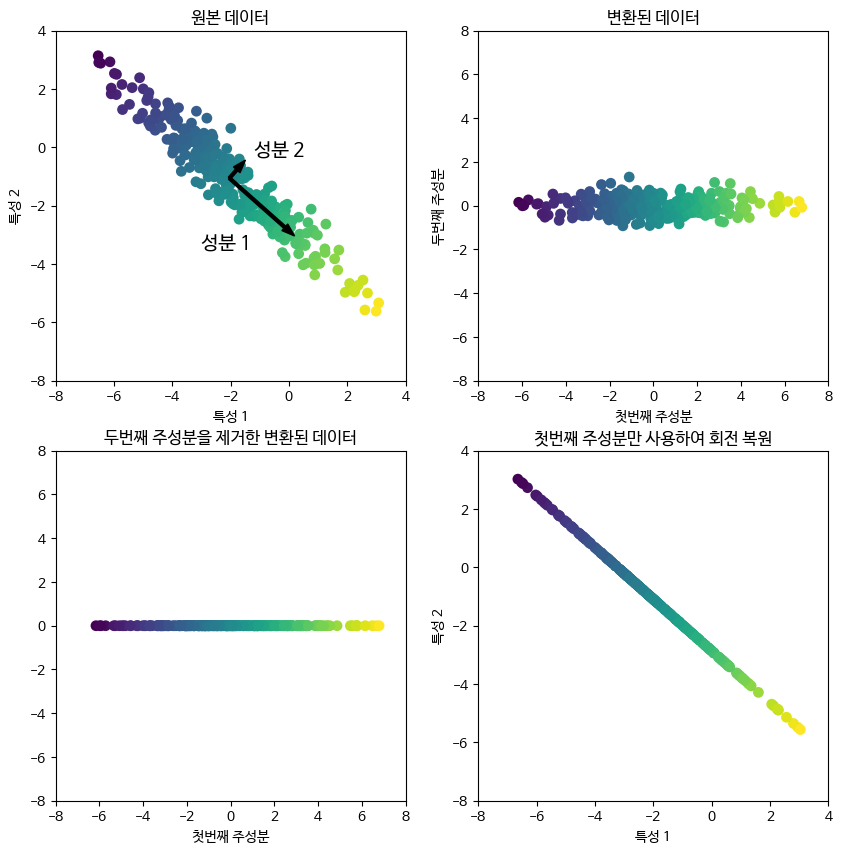

In [3]:
mglearn.plots.plot_pca_illustration()

- PCA
  - 1️⃣ 원본 데이터에서 분산이 가장 큰 방향 (예시에서는 성분 1)을 찾음
    - 이 방향 (또는 벡터)는 데이터에서 가장 많은 정보를 담고 있는 방향
    - 다른 말로, 특성들의 상관관계가 가장 큰 방향
  - 2️⃣ 첫 번째 방향과 직각인 방향 중 가장 많은 정보를 담고 있는 방향을 찾음
    - 2차원에서는 가능한 직각 방향이 하나뿐이지만 고차원에서는 무한히 많은 직각 방향이 있을 수 있음
    - 화살표의 방향은 의미 없음!
  - 3️⃣ 이 과정을 거쳐 찾은 방향을 데이터에 있는 주된 분산의 방향 (**주성분**)이라고 함
    - 일반적으로 특성 개수만큼 주성분이 있음
- 두 번째 그래프는 주성분 1과 2를 각각 x축과 y축에 나란하도록 회전한 것
  - 회전하기 전에 데이터에서 평균을 빼서 중심을 원점에 맞춤
  - 회전된 두 축은 연관되어 있지 않으므로 데이터의 상관관계 행렬이 대각선 방향을 제외하고는 0
- PCA는 주성분의 일부만 남기는 차원 축소 용도로 사용 가능
  - 세 번째 그래프: 2차원 데이터셋 → 1차원 데이터셋
  - 단순히 원본 특성 중 하나만 남기는 것이 아닌, 유용한 방향을 찾아서 그 방향의 성분 (첫 번째 주성분)을 유지하는 것
- 마지막으로 데이터에 다시 평균을 더하고 반대로 회전
  - 마지막 그래프: 데이터 포인트들은 원래 특성 공간에 놓여 있지만 첫 번째 주성분의 정보만 담고 있음
  - 데이터에서 노이즈를 제거하거나 주성분에서 유지되는 정보를 시각화하는 데 종종 사용

### 1.1 PCA를 적용해 유방암 데이터셋 시각화하기
- PCA가 가장 널리 사용되는 분야: 고차원 데이터셋의 시각화

In [4]:
# 데이터 로드
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

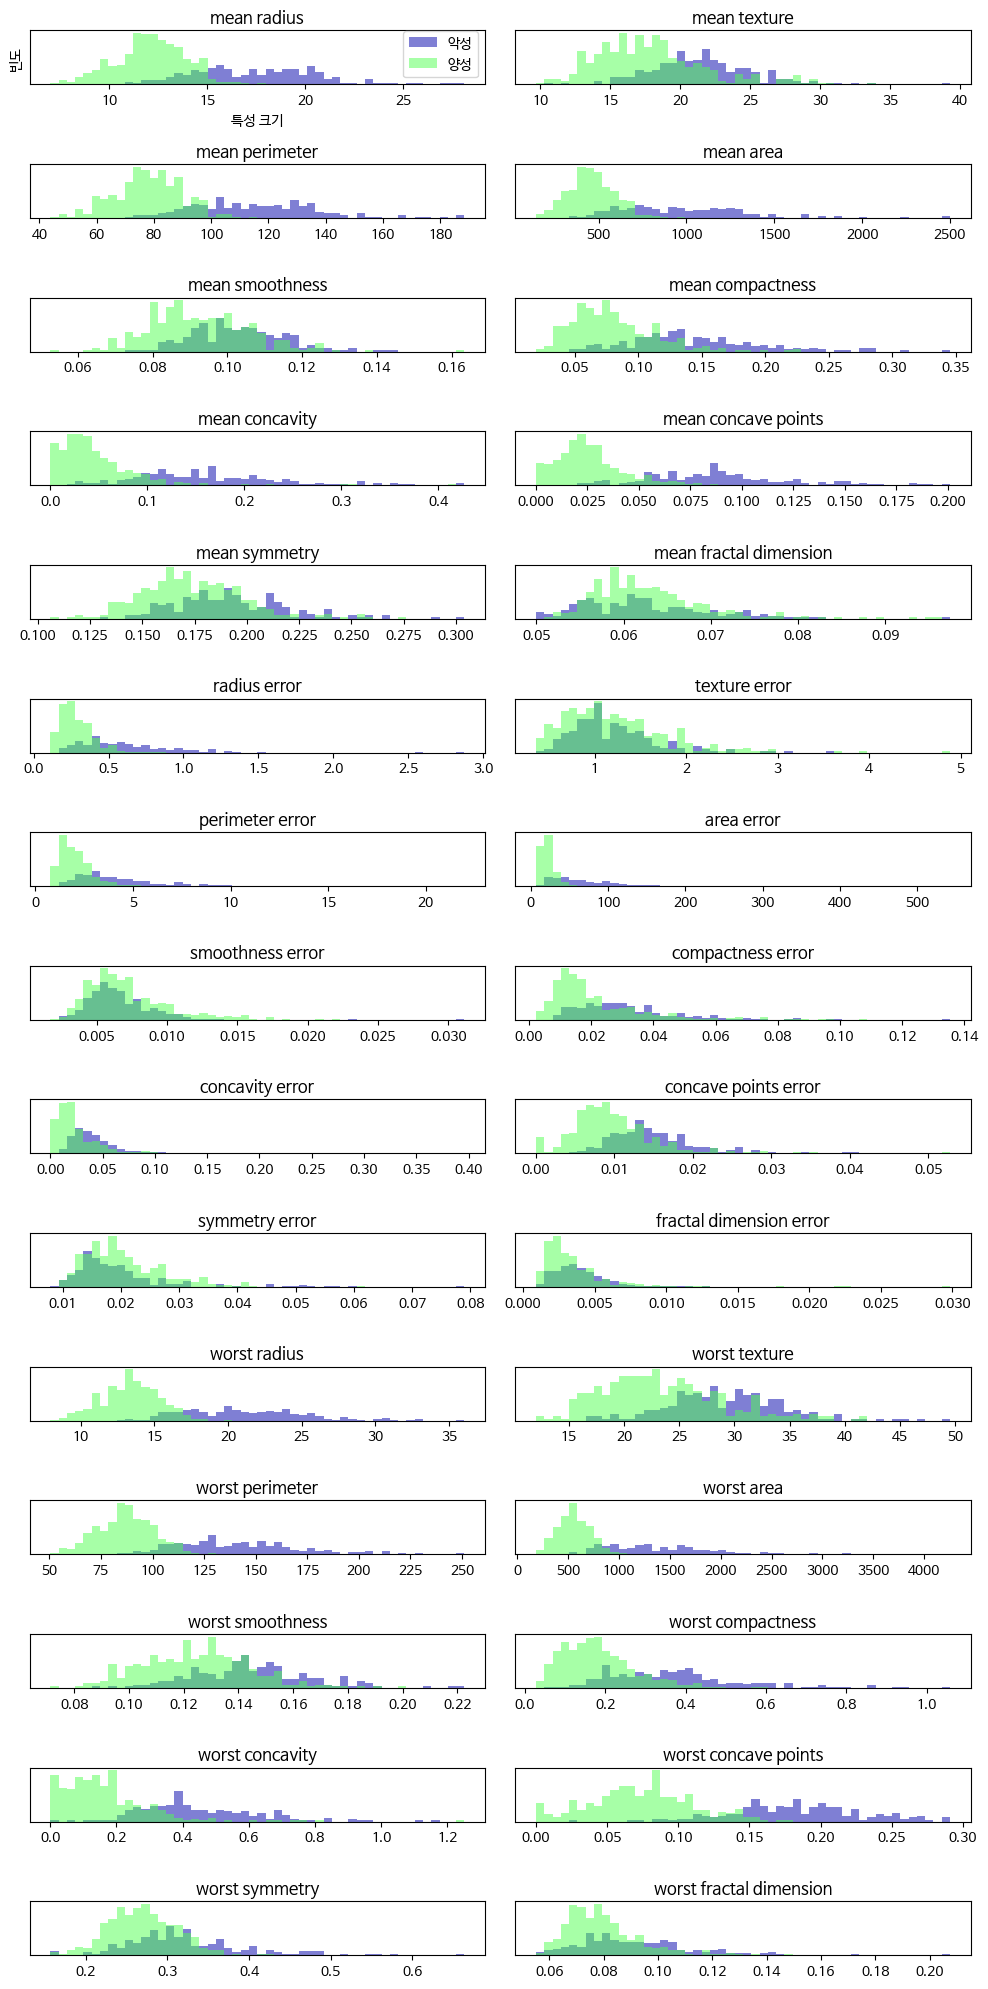

In [5]:
# 유방암 데이터의 클래스별 특성 히스토그램
# 양성과 악성 두 클래스에 대해 각 특성의 히스토그램

fig, axes = plt.subplots(15, 2, figsize=(10, 20))
malignant = cancer.data[cancer.target == 0]
benign = cancer.data[cancer.target == 1]

ax = axes.ravel()

for i in range(30):
  _, bins = np.histogram(cancer.data[:, i], bins=50)
  ax[i].hist(malignant[:, i], bins=bins, color=mglearn.cm3(0), alpha=.5)
  ax[i].hist(benign[:, i], bins=bins, color=mglearn.cm3(2), alpha=.5)
  ax[i].set_title(cancer.feature_names[i])
  ax[i].set_yticks(())

ax[0].set_xlabel("특성 크기")
ax[0].set_ylabel("빈도")
ax[0].legend(["악성", "양성"], loc="best")
fig.tight_layout()

plt.show()

- 위의 그래프들은 특성 간의 상호작용이나 이 상호작용이 클래스와 어떤 관련이 있는지는 알려주지 못함
- PCA를 사용하여 주요 상호작용을 찾아내면 더 나은 그래프를 그릴 수 있음 (처음 두 개의 주성분을 찾아 2차원 공간의 산점도로 시각화)

In [6]:
# StandardScaler로 데이터 스케일 조정
from sklearn.preprocessing import StandardScaler

cancer = load_breast_cancer()

scaler = StandardScaler()
scaler.fit(cancer.data)
X_scaled = scaler.transform(cancer.data)

In [7]:
# 데이터 차원을 줄이기 위해서는 PCA 객체에 얼마나 많은 성분을 유지할지 전달
from sklearn.decomposition import PCA

# 처음 두 개 주성분만 유지
pca = PCA(n_components=2)

pca.fit(X_scaled)

# 처음 두 개의 주성분을 사용해 데이터를 변환
X_pca = pca.transform(X_scaled)

print(f"원본 데이터 형태: {str(X_scaled.shape)}")
print(f"축소된 데이터 형태: {str(X_pca.shape)}")

원본 데이터 형태: (569, 30)
축소된 데이터 형태: (569, 2)


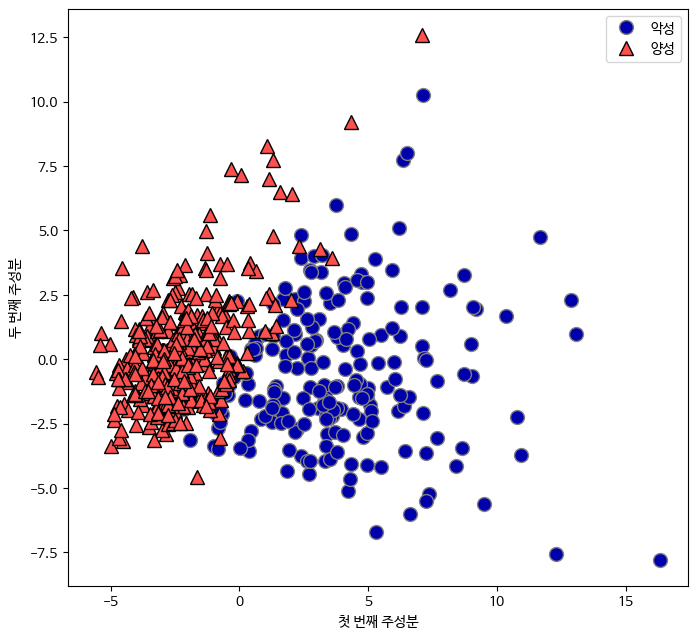

In [8]:
# 처음 두 개의 주성분을 사용해 그린 유방암 데이터셋의 2차원 산점도
# 클래스를 색깔로 구분

plt.figure(figsize=(8, 8))
mglearn.discrete_scatter(X_pca[:, 0], X_pca[:, 1], cancer.target)
plt.legend(["악성", "양성"], loc="best")
plt.gca().set_aspect("equal")
plt.xlabel("첫 번째 주성분")
plt.ylabel("두 번째 주성분")
plt.show()

- 회전축을 찾을 때 어떤 클래스 정보도 사용하지 않고 오직 데이터에 있는 상관관계만을 고려
- 2차원 공간에서 잘 구분되는 그래프 ➡️ 2차원 공간에서 직선 하나를 학습하는 선형 분류기로도 잘 구분 예측
- 악성 포인트가 양성 포인트보다 더 넓게 분포 (히스토그램에서도 확인 가능)
- PCA 단점: 두 축을 해석하기 쉽지 않음
  - 주성분: 원본 데이터에 있는 어떤 방향에 대응하는 여러 특성이 조합된 형태

In [9]:
# components_: 주성분 저장
print(f"PCA 주성분 형태: {pca.components_.shape}")

PCA 주성분 형태: (2, 30)


- `(각각의 주성분, 원본 데이터 특성에 대응하는 값)`
  - 행: 주성분의 중요도에 따라 정렬

In [10]:
print(f"PCA 주성분: {pca.components_}")

PCA 주성분: [[ 0.219  0.104  0.228  0.221  0.143  0.239  0.258  0.261  0.138  0.064
   0.206  0.017  0.211  0.203  0.015  0.17   0.154  0.183  0.042  0.103
   0.228  0.104  0.237  0.225  0.128  0.21   0.229  0.251  0.123  0.132]
 [-0.234 -0.06  -0.215 -0.231  0.186  0.152  0.06  -0.035  0.19   0.367
  -0.106  0.09  -0.089 -0.152  0.204  0.233  0.197  0.13   0.184  0.28
  -0.22  -0.045 -0.2   -0.219  0.172  0.144  0.098 -0.008  0.142  0.275]]


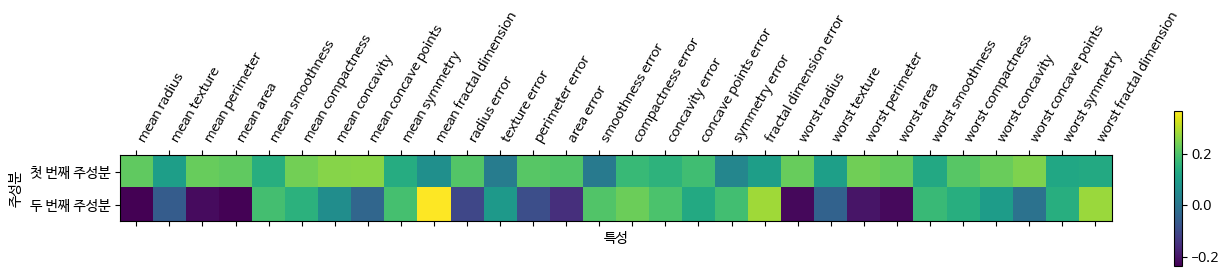

In [11]:
# 주성분 히트맵

plt.matshow(pca.components_, cmap="viridis")
plt.yticks([0, 1], ["첫 번째 주성분", "두 번째 주성분"])
plt.colorbar()
plt.xticks(range(len(cancer.feature_names)),
           cancer.feature_names, rotation=60, ha='left')
plt.xlabel("특성")
plt.ylabel("주성분")
plt.show()

- 첫 번째 주성분의 모든 특성은 같은 부호 == 모든 특성 사이에 공통의 상호관계 존재  ➡️ 한 특성의 값이 커지면 다른 값들도 높아짐
- 두 번째 주성분은 부호가 섞여 있음
- 모든 특성이 섞여 있기 때문에 축을 해석하기 쉽지 않음

### 1.2 고유얼굴(eigenface) 특성 추출
- PCA는 특성 추출에서도 이용 (e.g. 이미지를 다루는 애플리케이션)
- 원본 데이터 표현보다 분석하기에 더 적합한 표현을 찾을 수 있을 것이라는 생각에서 출발


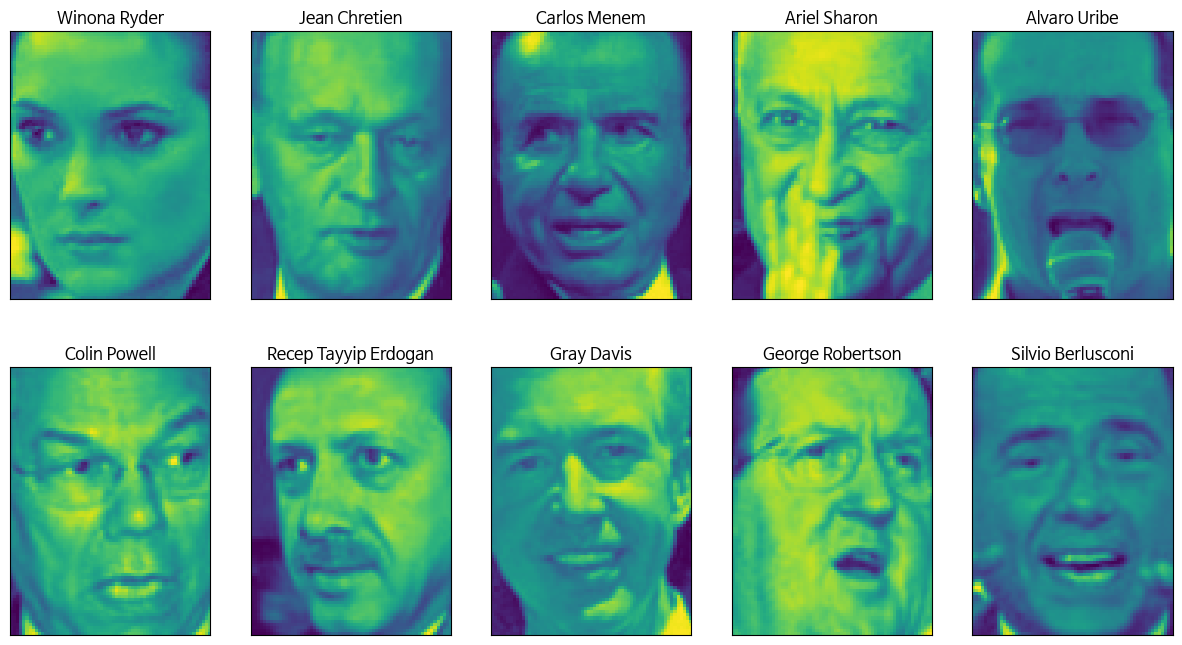

In [12]:
# LFW 데이터셋의 이미지 샘플
from sklearn.datasets import fetch_lfw_people

people = fetch_lfw_people(min_faces_per_person=20, resize=0.7)
image_shape = people.images[0].shape

fig, axes = plt.subplots(2, 5, figsize=(15, 8),
                         subplot_kw={'xticks': (), 'yticks': ()})

for target, image, ax in zip(people.target, people.images, axes.ravel()):
  ax.imshow(image)
  ax.set_title(people.target_names[target])

In [13]:
# 62명의 얼굴, 이미지 총 3023개, 각 이미지의 크기는 87*65픽셀
print(f"people.images.shape: {people.images.shape}")
print(f"클래스 개수: {len(people.target_names)}")

people.images.shape: (3023, 87, 65)
클래스 개수: 62


In [14]:
# 편중된 데이터

counts = np.bincount(people.target)

for i, (count, name) in enumerate(zip(counts, people.target_names)):
  print(f"{name:25} {count:3}", end=" ")
  if (i + 1) % 3 == 0:
    print()

Alejandro Toledo           39 Alvaro Uribe               35 Amelie Mauresmo            21 
Andre Agassi               36 Angelina Jolie             20 Ariel Sharon               77 
Arnold Schwarzenegger      42 Atal Bihari Vajpayee       24 Bill Clinton               29 
Carlos Menem               21 Colin Powell              236 David Beckham              31 
Donald Rumsfeld           121 George Robertson           22 George W Bush             530 
Gerhard Schroeder         109 Gloria Macapagal Arroyo    44 Gray Davis                 26 
Guillermo Coria            30 Hamid Karzai               22 Hans Blix                  39 
Hugo Chavez                71 Igor Ivanov                20 Jack Straw                 28 
Jacques Chirac             52 Jean Chretien              55 Jennifer Aniston           21 
Jennifer Capriati          42 Jennifer Lopez             21 Jeremy Greenstock          24 
Jiang Zemin                20 John Ashcroft              53 John Negroponte            31 

In [15]:
# 편중을 없애기 위해 사람마다 50개의 이미지만 추출

# people.target과 크기가 같은 불리언 배열 생성 (False 값으로 채워짐)
mask = np.zeros(people.target.shape, dtype=bool)

# 고유한 인물 이름을 순회하면서 해당 클래스에 속한 샘플들의 50개만 선택
# np.where(people.target == target): 해당 클래스에 속한 샘플들의 인덱스 배열 반환
# 해당 인덱스 위치의 mask를 True로 변환
for target in np.unique(people.target):
  mask[np.where(people.target == target)[0][:50]] = 1

X_people = people.data[mask]
y_people = people.target[mask]

# 픽셀 값을 0 ~ 1 스케일로 조정 (MinMaxScaler와 같은 효과)
X_people = X_people/225.

- 보통 얼굴 데이터베이스에는 사람의 수는 많지만 각 사람에 대한 이미지는 적음
- ➡️ 분류기를 훈련 시키기 어려움

In [16]:
# 분류하려는 얼굴과 가장 비슷한 얼굴 이미지를 찾는 1-최근접 이웃 분류기
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_people, y_people, stratify=y_people, random_state=0
)

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

print(f"1-최근접 이웃의 테스트 세트 점수: {round(knn.score(X_test, y_test), 2)}")

1-최근접 이웃의 테스트 세트 점수: 0.22


- 원본 픽셀 공간에서 거리를 계산하는 것은 매우 나쁜 방법
  - 픽셀을 사용해서 두 이미지를 비교할 때, 각 픽셀의 회색톤 값을 다른 이미지에서 동일한 위치에 있는 픽셀 값과 비교
  - 이런 방식은 사람이 얼굴 이미지를 인식하는 것과는 많이 다름
  - 얼굴의 특징을 잡아내기도 어려움
- PCA의 **화이트닝**(whitening) 옵션을 사용하여 주성분의 스케일이 같도록 조정

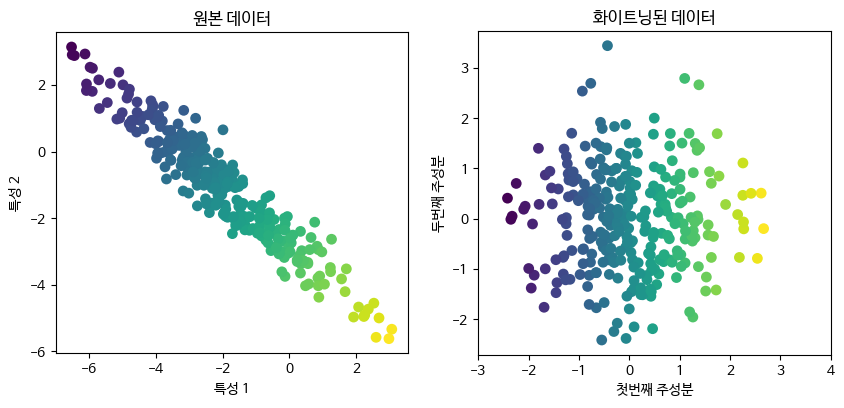

In [17]:
# 화이트닝 옵션을 사용한 PCA 데이터 변환
mglearn.plots.plot_pca_whitening()
# 데이터 회전 + 스케일 조정으로 원 모양이 됨

In [18]:
# 100개의 주성분을 추출하여 변환

pca = PCA(n_components=100, whiten=True, random_state=0).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"X_train_pca.shape: {X_train_pca.shape}")

X_train_pca.shape: (1547, 100)


In [19]:
# 변환된 데이터를 사용한 1-최근접 이웃 분류기

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_pca, y_train)

print(f"테스트 세트 정확도: {round(knn.score(X_test_pca, y_test), 2)}")

테스트 세트 정확도: 0.3


- 주성분: 입력 데이터 공간에서의 어떤 방향
- ➡️ 입력 차원은 87x65픽셀의 흑백 이미지이고, 이 공간의 어떤 방향도 87x65픽셀의 흑백 이미지

In [20]:
print(f"pca.components_.shape: {pca.components_.shape}")

pca.components_.shape: (100, 5655)


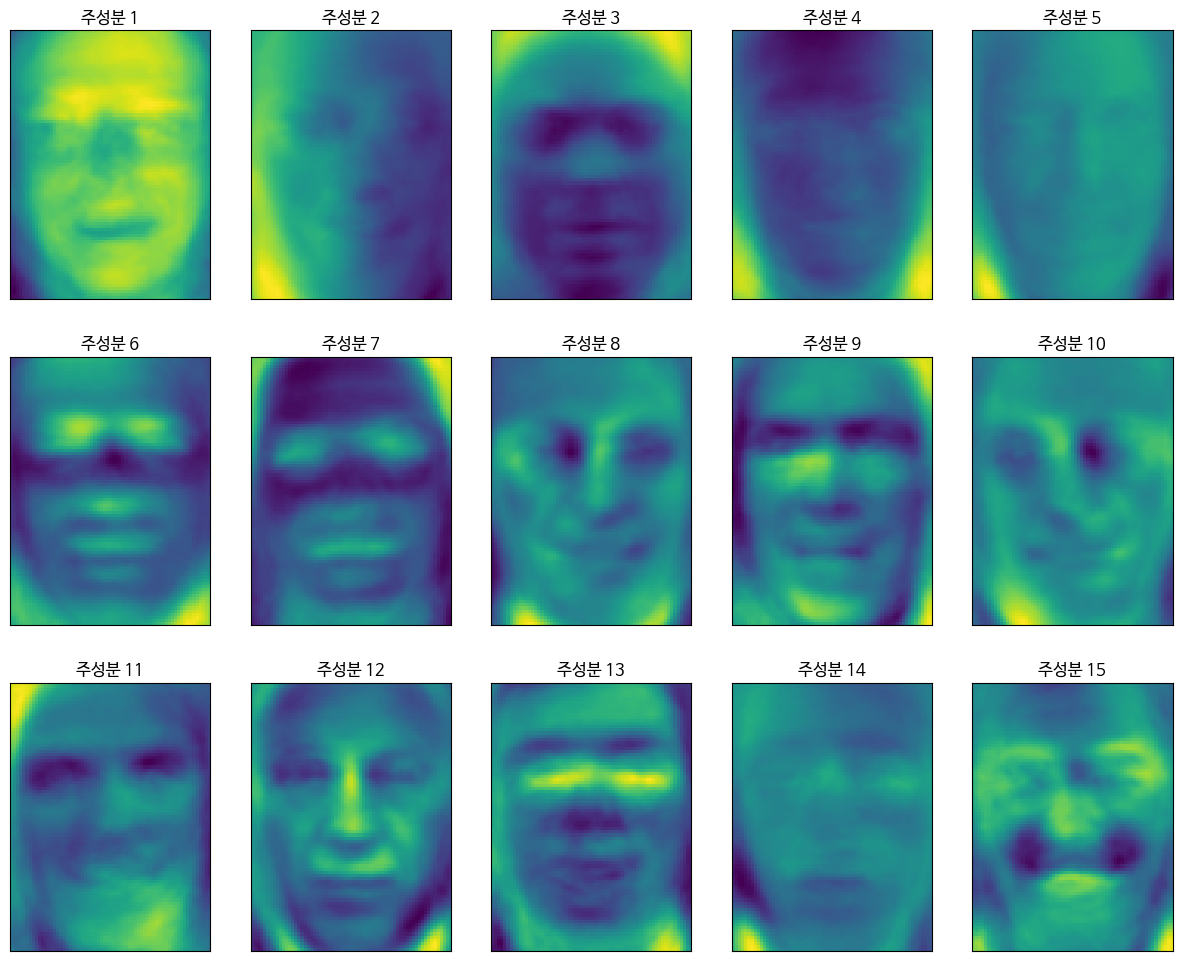

In [21]:
# 주성분 시각화
fig, axes = plt.subplots(3, 5, figsize=(15, 12),
                         subplot_kw={'xticks': (), 'yticks': ()})

for i, (component, ax) in enumerate(zip(pca.components_, axes.ravel())):
  ax.imshow(component.reshape(image_shape), cmap="viridis")
  ax.set_title(f"주성분 {i+1}")

- PCA 모델을 사용한 경우에는 얼굴의 배치와 조명이 큰 영향을 줌
- 하지만 사람은 얼굴의 배치나 조명부터 인지하지 않고, 나이, 성별, 표정, 머리 모양 같이 픽셀의 강도로 표현하기 어려운 속성들을 사용하여 얼굴을 구분
- ➡️ 알고리즘이 데이터를 해석하는 방식은 사람의 방식과 상당히 다름
- PCA는 테스트 포인트를 주성분의 가중치 합으로 나타내는 데 필요한 수치를 찾는 것으로도 해석 가능

________________________________________________________________________________
[Memory] Calling mglearn.plot_pca.pca_faces...
pca_faces(array([[0.002196, ..., 0.000935],
       ...,
       [0.000157, ..., 0.002248]], dtype=float32), 
array([[0.001046, ..., 0.001086],
       ...,
       [0.001772, ..., 0.001133]], dtype=float32))
_______________________________________________________pca_faces - 17.5s, 0.3min


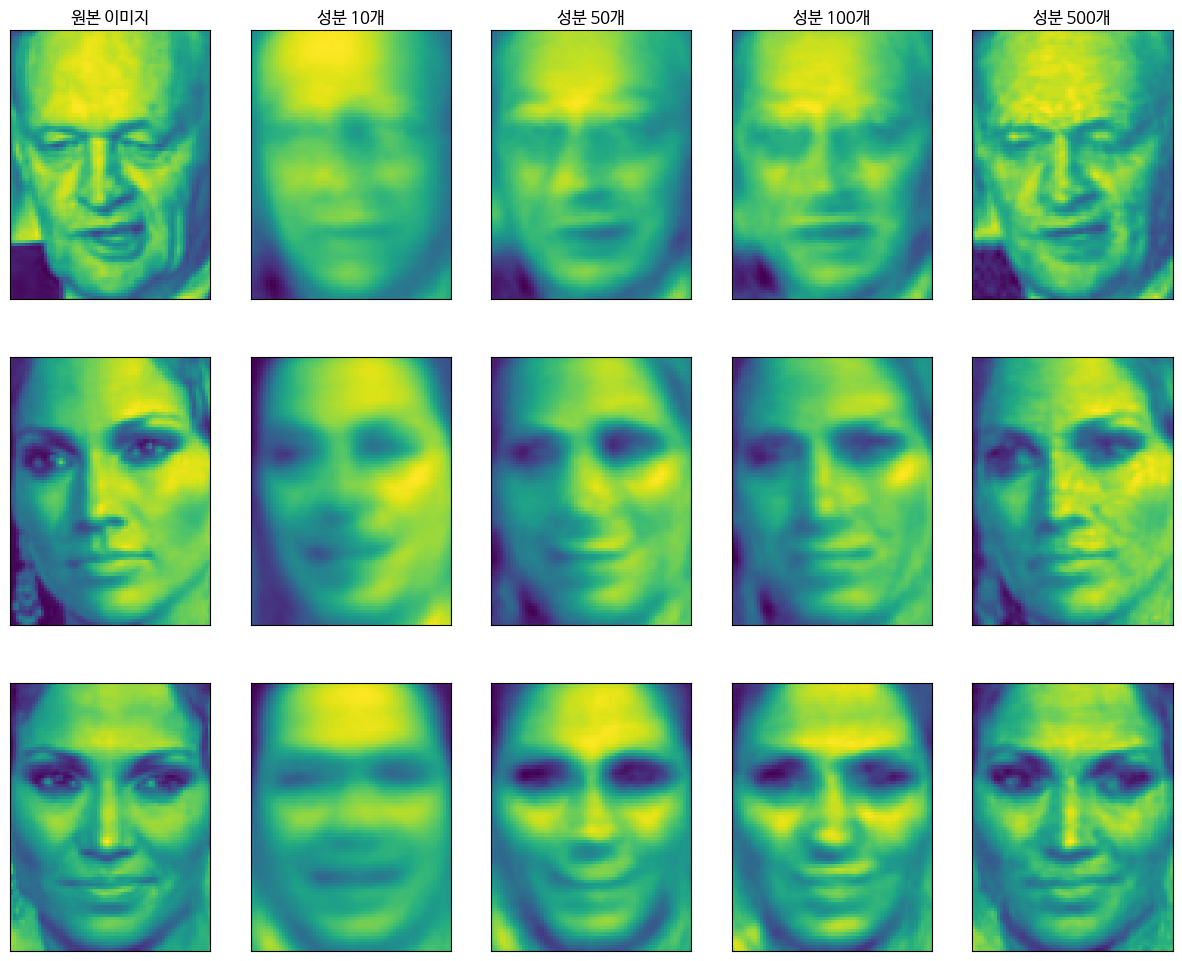

In [22]:
# 주성분 개수에 따른 세 얼굴 이미지의 재구성
mglearn.plots.plot_pca_faces(X_train, X_test, image_shape)

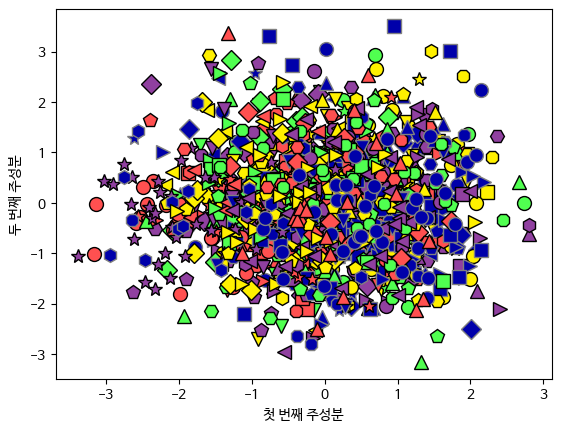

In [23]:
# 처음 두 개의 주성분을 이용하여 만든 데이터셋의 산점도
mglearn.discrete_scatter(X_train_pca[:, 0], X_train_pca[:, 1], y_train)
plt.xlabel("첫 번째 주성분")
plt.ylabel("두 번째 주성분")
plt.show()

### 1.3 설명된 분산의 비율
- 설명된 분산의 비율: 각 주성분은 원본 데이터셋의 한 방향이므로 각 주성분이 얼만큼의 분산을 표현하는지 비교 가능

In [24]:
# explained_variance_ratio_: 각 주성분의 설명된 분산의 비율을 제공
np.sum(pca.explained_variance_ratio_)

np.float32(0.89797103)

- 100개의 주성분으로 표현할 수 있는 얼굴 데이터셋의 분산은 약 90%
- 주성분은 가장 큰 분산의 방향을 차례대로 찾음 ➡️ 맨 처음 찾은 주성분이 재구성에 기여하는 정도가 가장 크고 나중으로 갈수록 작음

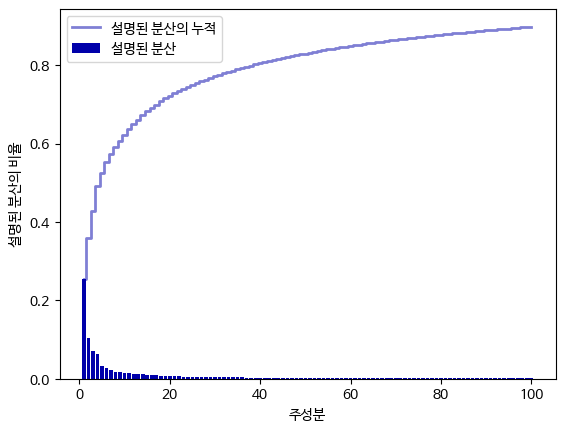

In [25]:
# 그래프를 통해 적절한 주성분의 개수 찾기
plt.bar(range(1, 101), pca.explained_variance_ratio_,
        align='center', label="설명된 분산")
plt.step(range(1, 101), np.cumsum(pca.explained_variance_ratio_),
         alpha=0.5, where='mid', label="설명된 분산의 누적")
plt.ylabel("설명된 분산의 비율")
plt.xlabel("주성분")
plt.legend()
plt.show()

In [26]:
# (위의 그래프) 주성분 40개로 80%의 분산을 표현 가능
# 주성분 40개로 지정하여 k-최근접 이웃 모델로 성능 확인

pca = PCA(n_components=40, whiten=True, random_state=0).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

knn.fit(X_train_pca, y_train)
print(f"테스트 세트 정확도: {round(knn.score(X_test_pca, y_test), 2)}")

테스트 세트 정확도: 0.3


In [27]:
# 80% 분산 비율에 해당하는 주성분을 찾도록 지정
# 찾은 주성분 개수는 n_components_에 저장

pca = PCA(n_components=0.8, whiten=True, random_state=0).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

knn.fit(X_train_pca, y_train)
print(f"테스트 세트 정확도: {round(knn.score(X_test_pca, y_test), 2)}")
print(f"주성분 개수: {pca.n_components_}")

테스트 세트 정확도: 0.29
주성분 개수: 39


## 02 비음수 행렬 분해 (NMF)
- 목적: 유용한 특성 추출, 차원 축소
- 어떤 성분의 가중치 합으로 각 데이터 포인트를 나타낼 수 있음
- 음수가 아닌 성분과 계수 값을 찾음
- ➡️ 주성분과 계수가 모두 0보다 크거나 같아야 함
- ➡️ 음수가 아닌 특성을 가진 데이터에만 적용 가능
- 음수가 아닌 가중치 합으로 데이터를 분해 ➡️ 독립된 소스를 추가하여 만들어진 데이터에서 유용함: 섞여 있는 원본에서 원본 성분 구분 가능 (e.g. 소리 추출, 유전자 표현 텍스트 데이터 등)
- 음수로 된 성분이나 계수가 만드는 상쇄 효과를 이해하기 어려운 PCA보다 대체로 NMF의 주성분이 해석하기 쉬움

### 2.1 인위적 데이터에 NMF 적용하기
- NMF로 데이터를 다루려먼 주어진 데이터가 양수인지 확인해야 함
  - 🚀 **데이터가 원점 (0, 0)에서 상대적으로 어디에 놓여 있는지가 중요**
  - 원점 (0, 0)에서 데이터로 가는 방향을 추출한 것으로 음수 미포함 성분을 이해 가능

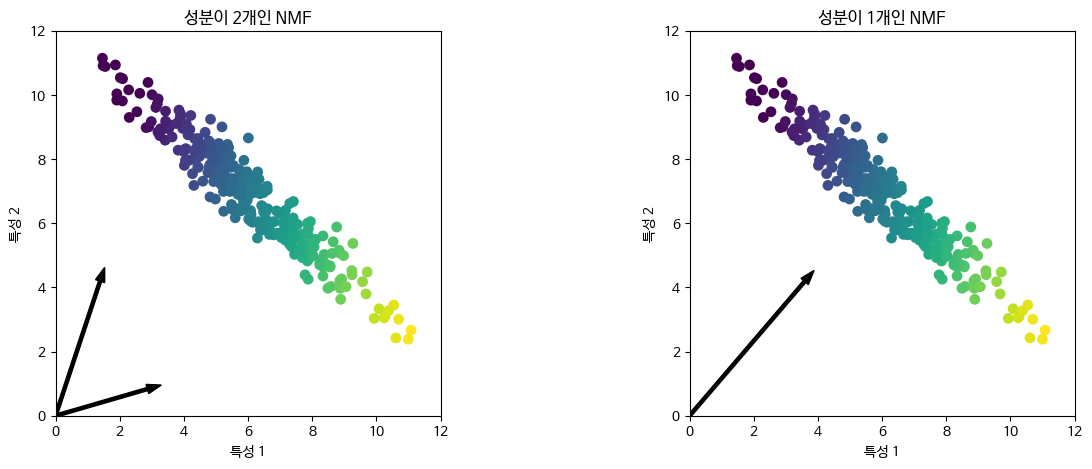

In [28]:
# NMF로 찾은 성분이 2개일 때와 1개일 때
mglearn.plots.plot_nmf_illustration()

- 성분이 2개인 NMF
  - 데이터셋의 모든 포인트를 양수로 이루어진 두 개의 성분으로 표현 가능
  - 데이터를 완벽하게 재구성할 수 있을 만큼 성분이 아주 많다면 (특성 개수만큼 많다면), 데이터의 각 특성의 끝에 위치한 포인트를 가리키는 방향을 선택할 것
- 성분이 1개인 NMF
  - 데이터를 가장 잘 표현할 수 있는 평균으로 향하는 성분을 만듦
  - **성분 개수를 줄이면 특정 방향이 제거되는 것 뿐만 아니라 전체 성분이 완전히 바뀜!** (모든 성분을 동등하게 취급)
- 난수 생성 초깃값에 따라 결과가 달라지며, 복잡한 경우에는 큰 차이를 만듦

### 2.2 얼굴 이미지에 NMF 적용하기
- NMF의 핵심 매개변수: 추출할 성분의 개수
  - 보통 특성의 개수보다 작음

In [29]:
# NMF 성분 개수에 따른 얼굴 이미지의 재구성
mglearn.plots.plot_nmf_faces(X_train, X_test[:3], image_shape)

KeyboardInterrupt: 

- PCA에 비해 조금 떨어지는 품질
  - PCA는 재구성 측면에서 최선의 방향을 찾음
  - NMF는 데이터를 인코딩하거나 재구성하는 용도보다는 데이터에 있는 유용한 패턴을 찾는 데 활용

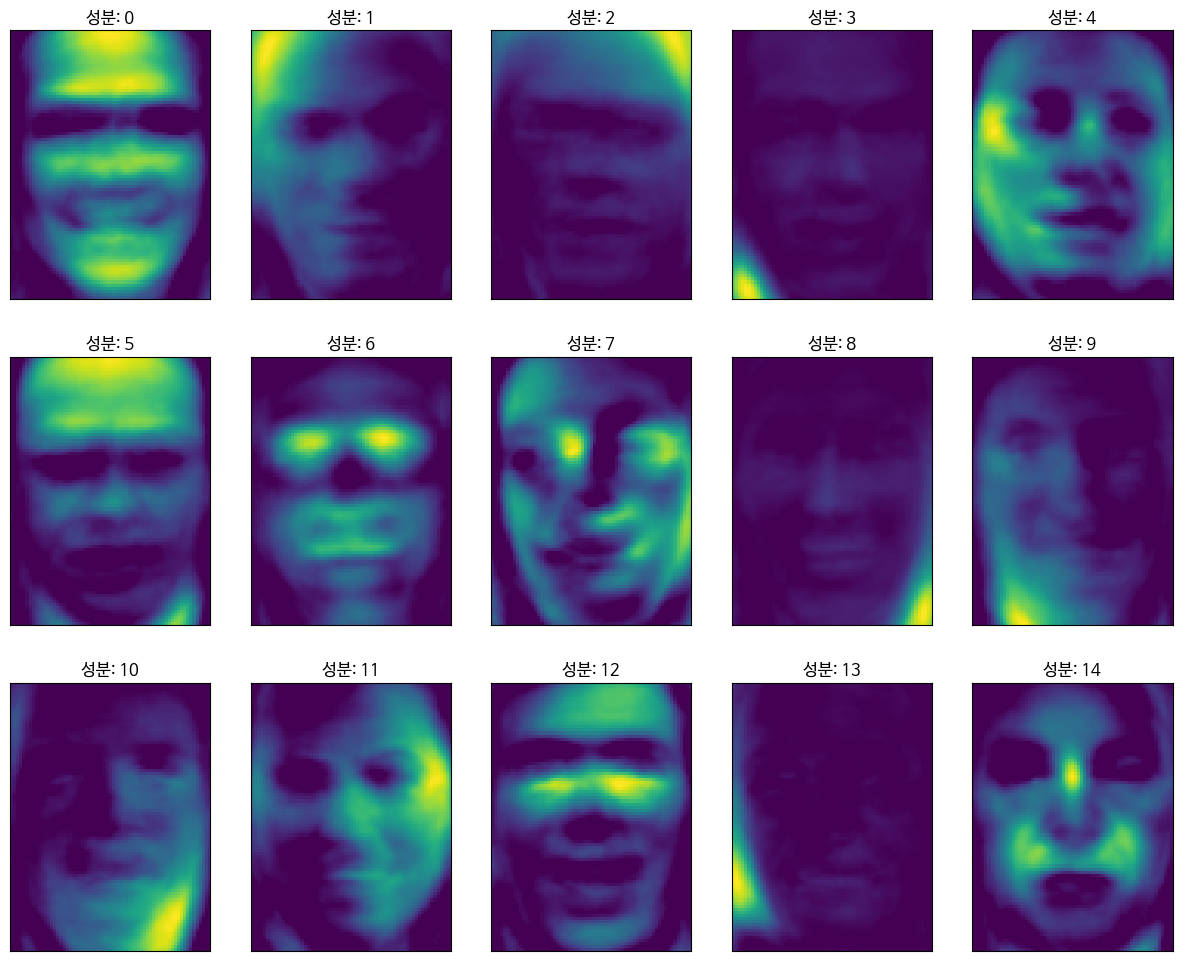

In [30]:
# 성분 15개 추출
from sklearn.decomposition import NMF

nmf = NMF(n_components=15, init="nndsvd", random_state=0,
          max_iter=1000, tol=1e-2)
nmf.fit(X_train)
X_train_nmf = nmf.transform(X_train)
X_test_nmf = nmf.transform(X_test)

fig, axes = plt.subplots(3, 5, figsize=(15, 12),
                         subplot_kw={'xticks': (), 'yticks': ()})

for i, (component, ax) in enumerate(zip(nmf.components_, axes.ravel())):
  ax.imshow(component.reshape(image_shape))
  ax.set_title(f"성분: {i}")

- 모두 양수 값이어서 PCA 성분보다 좀 더 얼굴 원형처럼 보임
- 성분 3은 오른쪽으로 조금 돌아간 얼굴로 보이고, 성분 7은 왼쪽으로 조금 회전한 얼굴로 보임

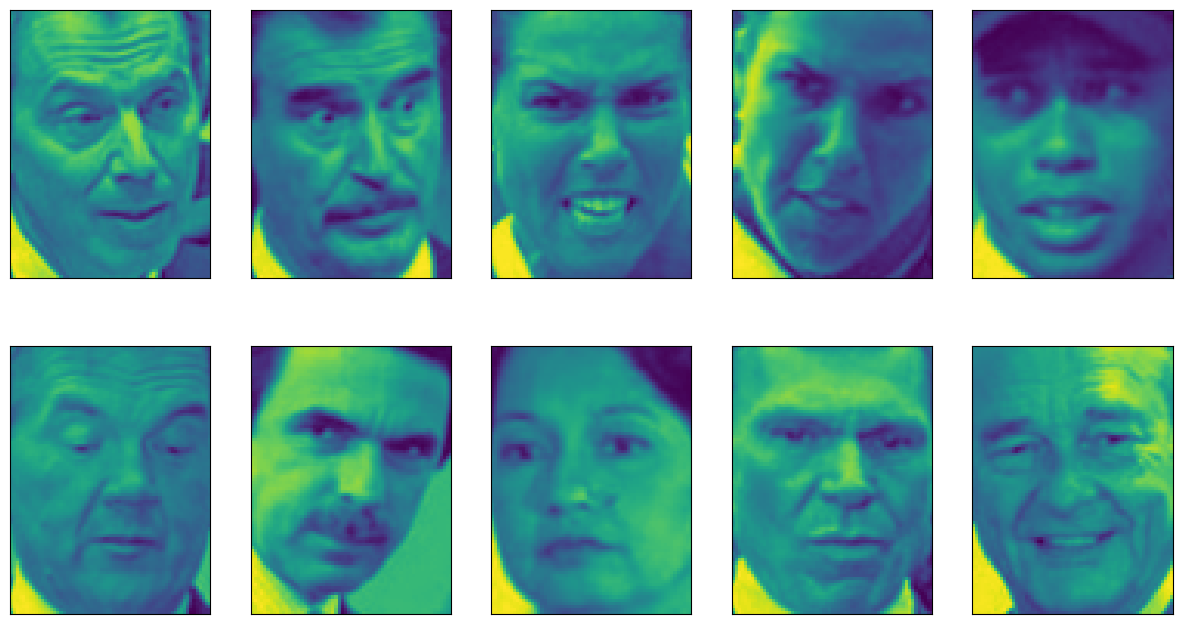

In [31]:
# 성분 3의 계수가 큰 얼굴들 (오른쪽으로 돌아간 얼굴들)
compn = 3

inds = np.argsort(X_train_nmf[:, compn])[::-1]
fig, axes = plt.subplots(2, 5, figsize=(15, 8),
                         subplot_kw={"xticks": (), "yticks": ()})

for i, (ind, ax) in enumerate(zip(inds, axes.ravel())):
  ax.imshow(X_train[ind].reshape(image_shape))

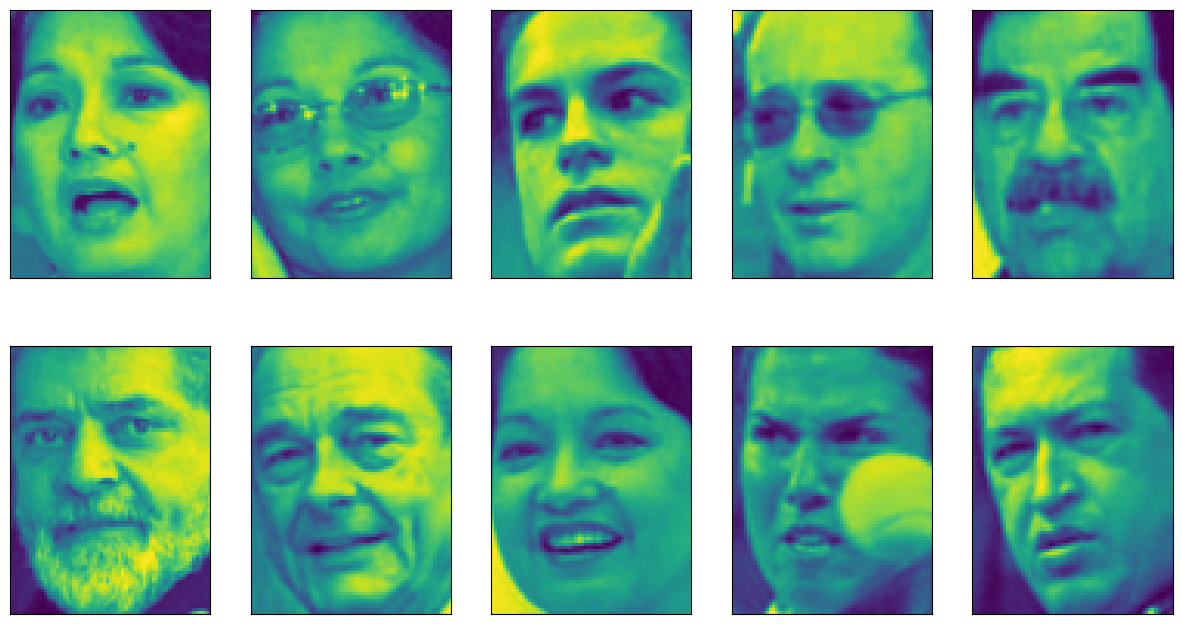

In [32]:
# 성분 7의 계수가 큰 얼굴들 (왼쪽으로 돌아간 얼굴들)
compn = 7

inds = np.argsort(X_train_nmf[:, compn])[::-1]
fig, axes = plt.subplots(2, 5, figsize=(15, 8),
                         subplot_kw={"xticks": (), "yticks": ()})

for i, (ind, ax) in enumerate(zip(inds, axes.ravel())):
  ax.imshow(X_train[ind].reshape(image_shape))

### 2.3 덧붙인 구조의 데이터에 NMF 적용하기

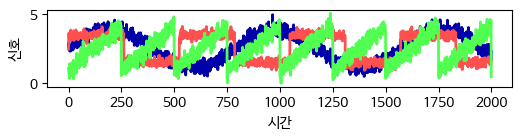

In [33]:
# 세 개의 서로 다른 입력으로부터 합성된 원본 신호

S = mglearn.datasets.make_signals()
plt.figure(figsize=(6, 1))
plt.plot(S, "-")
plt.xlabel("시간")
plt.ylabel("신호")
plt.show()

In [34]:
# 원본 데이터를 사용해 100개의 측정 데이터 만들기

A = np.random.RandomState(0).uniform(size=(100, 3))
X = np.dot(S, A.T)
print(f"측정 데이터 형태: {X.shape}")

측정 데이터 형태: (2000, 100)


In [35]:
# NMF를 사용해 세 개의 신호를 복원

nmf = NMF(n_components=3, init="nndsvd", random_state=42,
          max_iter=1000, tol=1e-2)
S_ = nmf.fit_transform(X)
print(f"복원한 신호 데이터 형태: {S_.shape}")

복원한 신호 데이터 형태: (2000, 3)


In [36]:
# 비교를 위해 PCA도 적용
pca = PCA(n_components=3)
H = pca.fit_transform(X)

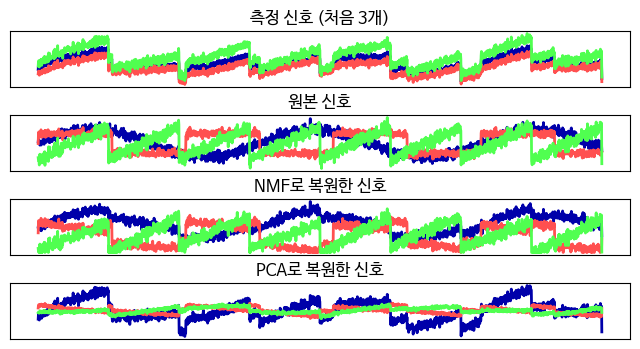

In [37]:
# NMF와 PCA를 사용해 복원한 신호

models = [X, S, S_, H]
names = ["측정 신호 (처음 3개)", "원본 신호", "NMF로 복원한 신호", "PCA로 복원한 신호"]

fig, axes = plt.subplots(4, figsize=(8, 4), gridspec_kw={"hspace": .5},
                         subplot_kw={"xticks": (), "yticks": ()})

for model, name, ax in zip(models, names, axes):
  ax.set_title(name)
  ax.plot(model[:, :3], "-")

- NMF는 원본 신호를 잘 복원했지만 PCA는 실패했고 데이터 변동의 대부분을 첫 번째 성분을 사용해 표현
  - ❗NMF로 생성한 성분은 순서가 없음에 유의 (위에서는 NMF 성분의 순서가 원본 신호와 같지만, 이는 우연)
  


## 03 t-SNE를 이용한 매니폴드 학습
- PCA의 단점: 알고리즘의 회전하고 방향을 제거하는 태생상 유용성이 떨어짐
- 매니폴드 학습 (manifold learning): 시각화 알고리즘으로 훨씬 복잡한 매핑을 만들어 더 나은 시각화를 제공 (특히 t-SNE 알고리즘을 많이 사용)
- 매니폴드 학습 알고리즘
  - 목적: 시각화 ➡️ 3개 이상의 특성을 뽑는 경우는 거의 없음
  - 일부 매니폴드 알고리즘은 테스트 세트에는 적용할 수 없고, 단지 훈련했던 데이터만 변환 가능 ➡️ EDA에서는 유용하지만 지도 학습용으로는 거의 사용하지 않음
- t-SNE
  - 각 데이터 포인트를 2차원에 무작위로 표현한 후 원본 특성 공간에서 가까운 포인트는 가깝게, 멀리 떨어진 포인트는 멀어지게 만듦
  - 멀리 떨어진 포인트와 거리를 보존하는 것보다 가까이 있는 포인트에 더 많은 비중을 둠 ➡️ 이웃 데이터 포인트에 대한 정보를 보존하려 노력

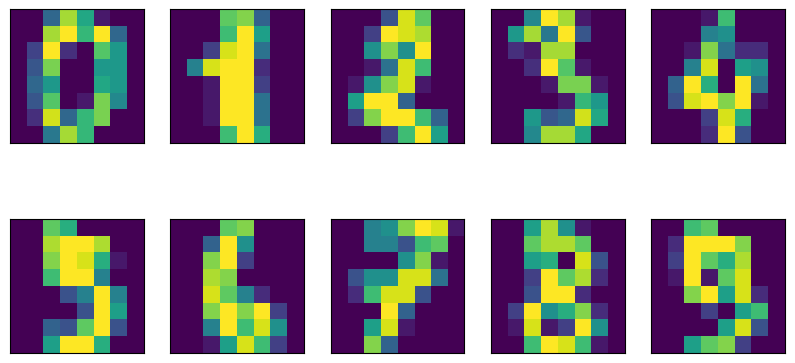

In [39]:
# 숫자 데이터셋의 샘플 이미지
from sklearn.datasets import load_digits

digits = load_digits()

fig, axes = plt.subplots(2, 5, figsize=(10, 5),
                         subplot_kw={"xticks": (), "yticks": ()})

for ax, img in zip(axes.ravel(), digits.images):
  ax.imshow(img)

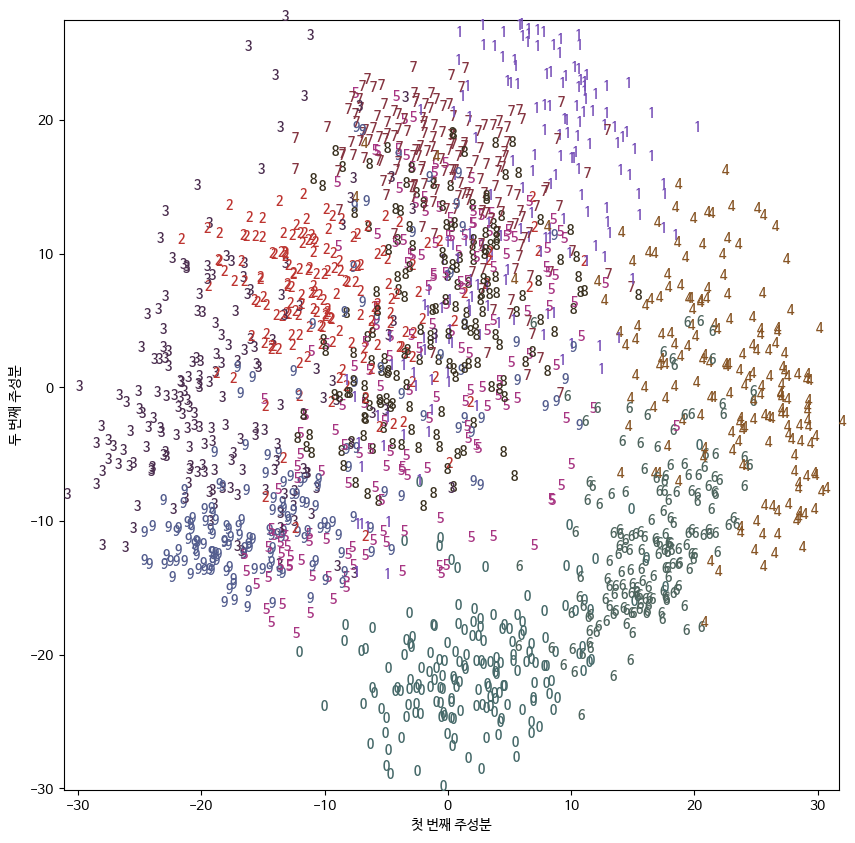

In [41]:
# PCA 사용: 처음 두 개의 주성분을 사용한 숫자 데이터셋의 산점도

# PCA 모델 생성
pca = PCA(n_components=2)
pca.fit(digits.data)

# 처음 두 개의 주성분으로 숫자 데이터를 변환
digits_pca = pca.transform(digits.data)

colors = ["#476A6A", "#7851B8", "#BD3430", "#4A2D4E", "#875525",
          "#A83683", "#4E655E", "#853541", "#3A3120", "#535D8E"]
plt.figure(figsize=(10, 10))
plt.xlim(digits_pca[:, 0].min(), digits_pca[:, 0].max())
plt.ylim(digits_pca[:, 1].min(), digits_pca[:, 1].max())

for i in range(len(digits.data)):
  plt.text(digits_pca[i, 0], digits_pca[i, 1], str(digits.target[i]),
           color=colors[digits.target[i]],
           fontdict={"weight": "bold", "size": 9})

plt.xlabel("첫 번째 주성분")
plt.ylabel("두 번째 주성분")
plt.show()

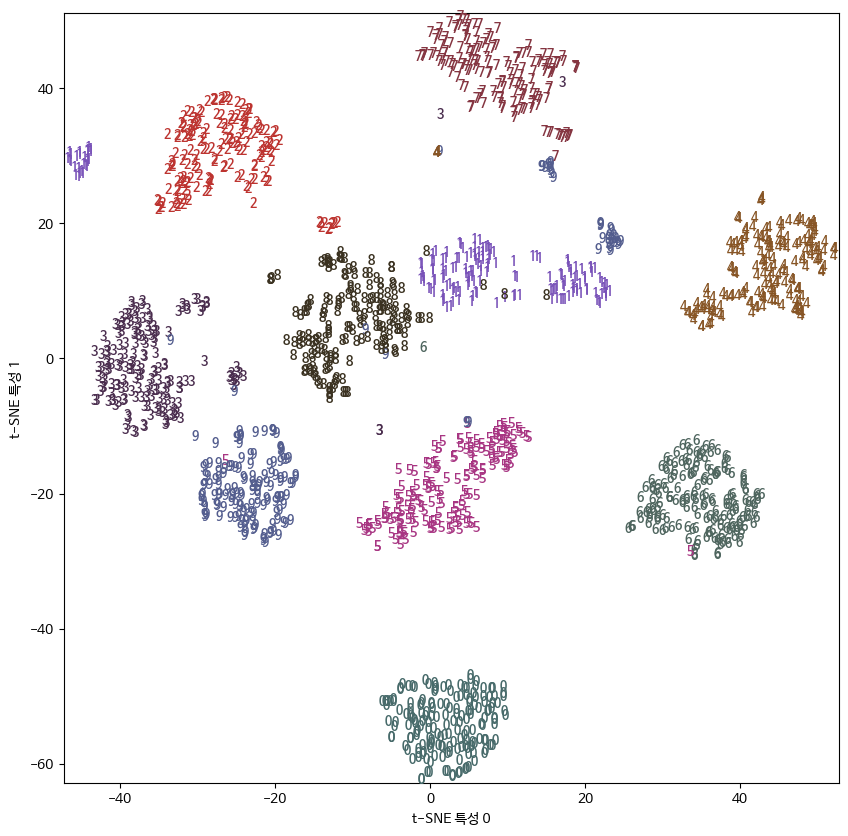

In [44]:
# t-SNE로 찾은 두 개의 성분을 사용한 숫자 데이터셋의 산점도
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.manifold import TSNE
tsne = TSNE(random_state=42)
digits_tsne = tsne.fit_transform(digits.data)

plt.figure(figsize=(10, 10))
plt.xlim(digits_tsne[:, 0].min(), digits_tsne[:, 0].max()+1)
plt.ylim(digits_tsne[:, 1].min(), digits_tsne[:, 1].max()+1)

for i in range(len(digits.data)):
  plt.text(digits_tsne[i, 0], digits_tsne[i, 1], str(digits.target[i]),
           color=colors[digits.target[i]],
           fontdict={"weight": "bold", "size": 9})

plt.xlabel("t-SNE 특성 0")
plt.ylabel("t-SNE 특성 1")
plt.show()